# Sepsis Prediction - Machine Learning Project

This project aims to predict sepsis risk using clinical measurements.
The project is structured in two classification levels:

Level 1:
Binary classification predicting whether the patient will develop sepsis.

Level 2:
Multiclass classification predicting the type of sepsis risk.

Models used:
- Naive Bayes
- Decision Tree

Evaluation metrics:
- Accuracy
- F1-score
- ROC-AUC

## Import and Setup

In [7]:
import os
import sys

# Permette di importare da src/
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
SRC_PATH = os.path.join(PROJECT_ROOT, "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Setup Successful")
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("Working directory:", os.getcwd())
print("Project root:", PROJECT_ROOT)

Setup Successful
Python version: 3.14.3
Pandas version: 3.0.1
Working directory: D:\0_Lavoro\Progetti\ML\ML_Sepsis\notebooks
Project root: D:\0_Lavoro\Progetti\ML\ML_Sepsis


## Snapshot Upload

The dataset used for the experiments is a preprocessed patient snapshot dataset.
Each row represents a patient and contains aggregated clinical measurements.

The snapshot format allows the transformation of time-series ICU data
into a tabular structure suitable for machine learning models.

In [8]:
# Upload
from preprocessing import load_snapshot

DATA_PATH = "data/snapshot.csv"
df = load_snapshot(DATA_PATH)
df.shape

(40336, 37)

### Macro Label Distribution

The distribution of the macro labels is analyzed to understand how the
different clinical categories are represented in the dataset.

Examining class distribution is important because machine learning models can be affected by class imbalance.

Macro label distribution:


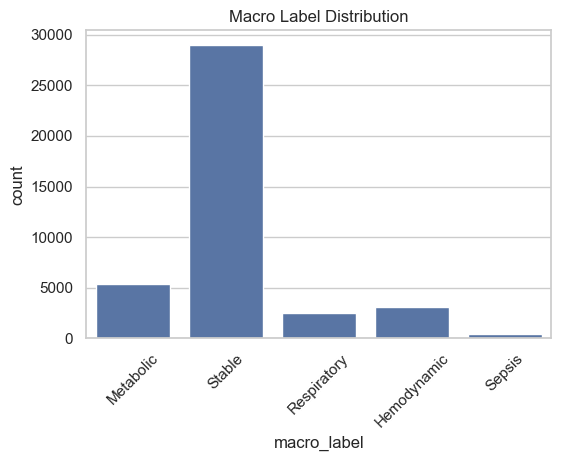

In [9]:
# Distribuzione
print("Macro label distribution:")
df["macro_label"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="macro_label")
plt.title("Macro Label Distribution")
plt.xticks(rotation=45)
plt.show()

The plot provides a visual representation of the class frequencies, highlighting potential imbalances among the macro labels.

## Split Train/Test

The dataset is divided into training and test sets in order to evaluate the model on unseen data.

The training set is used to train the models, while the test set is used
only for final evaluation to estimate generalization performance.

In [10]:
# Train e Test
from preprocessing import split_train_test, split_level1, split_level2

train_df, test_df = split_train_test(df)

X_train_lvl1, y_train_lvl1, X_test_lvl1, y_test_lvl1 = split_level1(train_df, test_df)
X_train_lvl2, y_train_lvl2, X_test_lvl2, y_test_lvl2 = split_level2(train_df, test_df)

print("Level 1 train shape:", X_train_lvl1.shape)
print("Level 2 train shape:", X_train_lvl2.shape)

Level 1 train shape: (32268, 35)
Level 2 train shape: (31927, 35)


# Level-Specific Dataset Preparation

Two different datasets are prepared for the two classification tasks:

### Level 1:
Binary classification predicting whether a patient will develop sepsis.
### Level 2:
Multiclass classification based on macro clinical labels representing
different levels of severity.

## Level 1 – Binary Classification
The goal of Level 1 is to predict whether a patient will develop sepsis.

A Decision Tree classifier was used due to its interpretability and ability
to capture non-linear relationships between clinical variables.

The model was trained on the training set and evaluated on the test set
using the following metrics:

- Accuracy
- F1-score
- ROC-AUC

In [11]:
# LIVELLO 1 - Riconoscimento casi di Sepsi
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from utils import eval_binary, best_threshold_f1, apply_threshold

tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train_lvl1, y_train_lvl1)

y_pred = tree_model.predict(X_test_lvl1)
y_proba = tree_model.predict_proba(X_test_lvl1)[:, 1]

eval_binary(y_test_lvl1, y_pred, y_proba, title="Decision Tree - Level 1")

threshold, f1, precision, recall = best_threshold_f1(y_test_lvl1, y_proba)

print("Best threshold:", threshold)
print("Best F1:", f1)
print("Precision:", precision)
print("Recall:", recall)

custom_pred = apply_threshold(y_proba, threshold)
eval_binary(y_test_lvl1, custom_pred, None, title="Custom Threshold")



=== Decision Tree - Level 1 ===

Confusion matrix:
 [[5352 2631]
 [  27   58]] 

              precision    recall  f1-score   support

           0     0.9950    0.6704    0.8011      7983
           1     0.0216    0.6824    0.0418        85

    accuracy                         0.6706      8068
   macro avg     0.5083    0.6764    0.4214      8068
weighted avg     0.9847    0.6706    0.7931      8068

ROC-AUC: 0.7392842142493976
Best threshold: 0.8799624967421512
Best F1: 0.06206896551724138
Precision: 0.21176470588235294
Recall: 0.09599999999964944

=== Custom Threshold ===

Confusion matrix:
 [[7711  272]
 [  67   18]] 

              precision    recall  f1-score   support

           0     0.9914    0.9659    0.9785      7983
           1     0.0621    0.2118    0.0960        85

    accuracy                         0.9580      8068
   macro avg     0.5267    0.5888    0.5372      8068
weighted avg     0.9816    0.9580    0.9692      8068



## Level 2 – Multiclass Classification
In Level 2 the goal is to classify patients into different clinical macro-labels derived from the dataset.

These labels do not explicitly represent early stages of sepsis.
Instead, they group clinical conditions that implicitly correspond to different levels of severity.

Therefore, although the classes are not direct risk levels,
they reflect different clinical states associated with increasing severity of the condition.

In [12]:
# LIVELLO 2 - Classificazione Macro Labels
from utils import eval_multiclass, tree_importances

tree_lvl2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

tree_lvl2.fit(X_train_lvl2, y_train_lvl2)

y_pred_lvl2 = tree_lvl2.predict(X_test_lvl2)

eval_multiclass(y_test_lvl2, y_pred_lvl2, title="Decision Tree - Level 2")

tree_importances(tree_lvl2, X_train_lvl2.columns, top_k=10)


=== Decision Tree - Level 2 ===

Macro-F1: 0.9794901199201452
Confusion matrix (labels order):
['Hemodynamic', 'Metabolic', 'Respiratory', 'Stable']
[[ 602    4    0   21]
 [   0 1058    1    7]
 [   0    2  446   43]
 [   0    0    0 5799]] 

              precision    recall  f1-score   support

 Hemodynamic     1.0000    0.9601    0.9797       627
   Metabolic     0.9944    0.9925    0.9934      1066
 Respiratory     0.9978    0.9084    0.9510       491
      Stable     0.9879    1.0000    0.9939      5799

    accuracy                         0.9902      7983
   macro avg     0.9950    0.9652    0.9795      7983
weighted avg     0.9903    0.9902    0.9901      7983


Top Feature Importances:
        Glucose  0.458703
             HR  0.167026
            SBP  0.155132
            MAP  0.089039
           Resp  0.084326
          O2Sat  0.045774
           Temp  0.000000
            DBP  0.000000
     BaseExcess  0.000000
           HCO3  0.000000

Tree depth: 5
Number of leaves: 2

# Conclusions

- Level 1 shows strong class imbalance (≈1% Sepsis)
- Decision Tree with depth control outperforms Naive Bayes
- Threshold optimization improves F1-score
- Level 2 performance is high due to deterministic surrogate labels
- Feature importance confirms rule-based separation

## Feature Importance
The most important features include physiological variables such as
heart rate and oxygen saturation, which are clinically relevant indicators of patient instability.

## Model Interpretability
Decision Trees allow interpretation of the decision process.
For example, high heart rate and low oxygen saturation often indicate increased sepsis risk.

## Final Considerations

The models were able to capture relevant patterns in the data.
Decision Trees performed better than Naive Bayes, likely because they capture nonlinear relationships between clinical variables.
However, the dataset may contain noisy or surrogate labels which could affect model performance.

It is also important to note that the macro-labels used in this stage are surrogate clinical categories rather than direct diagnostic stages of sepsis.
Therefore, the model predictions should be interpreted as indicators of clinical patterns rather than definitive medical diagnoses.
